In [58]:
!pip install kagglehub

import kagglehub
import pandas as pd
import os

# Download the latest version of the dataset
path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")

print("Path to dataset files:", path)

# Find the CSV file (assuming there's one in the folder)
for file in os.listdir(path):
    if file.endswith(".csv"):
        csv_path = os.path.join(path, file)
        break

# Load into pandas DataFrame
df = pd.read_csv(csv_path)

Path to dataset files: /root/.cache/kagglehub/datasets/fedesoriano/stroke-prediction-dataset/versions/1


In [59]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

# Dictionary to store encoders and mappings
label_encoders = {}

# Encode categorical columns and show mappings
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

    # Display mapping
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"Encoding for column '{col}': {mapping}")

# Drop rows with missing values (optional, or handle missing separately)
df = df.dropna()

# Separate features and target
X = df.drop(columns=['id', 'stroke'])  # drop 'id' and target column
y = df['stroke'].values.astype(int)

print(X)
print(X.shape)
print(y)
print(y.shape)

Encoding for column 'gender': {'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}
Encoding for column 'ever_married': {'No': np.int64(0), 'Yes': np.int64(1)}
Encoding for column 'work_type': {'Govt_job': np.int64(0), 'Never_worked': np.int64(1), 'Private': np.int64(2), 'Self-employed': np.int64(3), 'children': np.int64(4)}
Encoding for column 'Residence_type': {'Rural': np.int64(0), 'Urban': np.int64(1)}
Encoding for column 'smoking_status': {'Unknown': np.int64(0), 'formerly smoked': np.int64(1), 'never smoked': np.int64(2), 'smokes': np.int64(3)}
      gender   age  hypertension  heart_disease  ever_married  work_type  \
0          1  67.0             0              1             1          2   
2          1  80.0             0              1             1          2   
3          0  49.0             0              0             1          2   
4          0  79.0             1              0             1          3   
5          1  81.0             0              0   

In [ ]:
import numpy as np

def entropy(labels):
    distinct_labels,label_counts = np.unique(labels, return_counts=True)
    probabilities = label_counts/(len(labels))
    return -1*np.sum(probabilities*np.log2(probabilities))

In [61]:
# AUTOGRADER TEST CASE - VISIBLE

assert entropy(np.array([1, 1, 1, 1])) == 0.0, "Test case 1 failed: Expected entropy 0.0"
assert np.isclose(entropy(np.array([0, 0, 1, 1])), 1.0), "Test case 2 failed: Expected entropy 1.0"
assert np.isclose(entropy(np.array([0, 0, 0, 1])), -(0.75 * np.log2(0.75) + 0.25 * np.log2(0.25))), "Test case 3 failed"
print("✅ All visible test cases passed!")

✅ All visible test cases passed!


In [ ]:
def compute_information_gain(data, feature_index, labels):

    initial_entropy = entropy(labels)# find initial entropy for all labels

    distinct_values, counts = np.unique(data[:, feature_index], return_counts=True)

    highest_info_gain = -1 #initializing variables to store max info gain and the corresponding threshold
    split_threshold = None

    for i in range(1, len(distinct_values)):# looping through all distinct data points
      threshold = (distinct_values[i-1] + distinct_values[i]) / 2 #mid point 2 consecutive data points set as threshold
      left_split = data[:, feature_index] <= threshold # ferforming left, right split based on threshold
      right_split = data[:, feature_index] > threshold
      left_labels = labels[left_split]
      right_labels = labels[right_split]
      left_entropy = entropy(left_labels)# finding left and right entropy
      right_entropy = entropy(right_labels)
      weighted_entropy = (np.sum(left_split) / len(labels)) * left_entropy + (np.sum(right_split) / len(labels)) * right_entropy # finding weighted entropy
      info_gain = initial_entropy - weighted_entropy # finding information gain

      if info_gain > highest_info_gain: # comparing to find max info gain and corresponding threshold
        highest_info_gain = info_gain
        split_threshold = threshold

    return highest_info_gain, split_threshold

In [63]:
data = np.array([[1, 0], [1, 1], [0, 1], [0, 0]])
labels = np.array([0, 1, 1, 0])
info_gain, threshold=compute_information_gain(data, 0, labels)
assert np.isclose(info_gain, 0.0, atol=0.01)


In [ ]:
def best_split(data, labels):

    highest_info_gain = 0 # initializing variables to store max info gain, best split threshold and best feature for splitting
    best_spilt_threshold = None
    best_feature = None

    num_features = data.shape[1] # extracting number of features
    for feature_index in range(num_features):# looping through all features
      info_gain, split_threshold = compute_information_gain(data,feature_index,labels)# calculating info gain for the current feature
      if info_gain > highest_info_gain:#  comparing to find max info gain and corresponding threshold and the corresponding feature
        highest_info_gain = info_gain
        best_spilt_threshold = split_threshold
        best_feature = feature_index
    return best_feature, best_spilt_threshold

In [65]:
class DecisionTreeNode:
    """Class for a decision tree node."""
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

class DecisionTree:
    def __init__(self, max_depth=3):
        self.max_depth = max_depth
        self.root = None

    def fit(self, data, labels, depth=0):
        """Recursively builds the decision tree."""
        # Base case: Stop splitting if pure or max depth reached
        if depth == self.max_depth or len(np.unique(labels)) == 1: #Why?
        # Answer: If the max depth of the tree is reached or if the split is pure (having only 1 unique label), then the splitting is to be stopped
            return DecisionTreeNode(value=np.bincount(labels).argmax()) #Why?
            # Answer: Finding out the maxium occuring label in the node of the tree then defining with the node so we can predict it

        # Find best feature and threshold
        best_feature, best_threshold = best_split(data, labels)

        # Partition data
        left_mask = data[:, best_feature] <= best_threshold
        right_mask = ~left_mask

        if np.all(left_mask) or np.all(right_mask):  # Prevent infinite splitting
            return DecisionTreeNode(value=np.bincount(labels).argmax())

        left_child = self.fit(data[left_mask], labels[left_mask], depth + 1)
        right_child = self.fit(data[right_mask], labels[right_mask], depth + 1)

        return DecisionTreeNode(feature=best_feature, threshold=best_threshold, left=left_child, right=right_child)

    def train(self, data, labels):
        """Initialize tree training."""
        self.root = self.fit(data, labels, depth=0)



In [66]:
def predict_sample(node, sample):
    """Recursively predict the label for a single sample."""
    if node.value is not None:
        return node.value
    if sample[node.feature] <= node.threshold:
        return predict_sample(node.left, sample)
    else:
        return predict_sample(node.right, sample)

def predict(tree, data):
    """Predict labels for multiple samples."""
    return np.array([predict_sample(tree.root, sample) for sample in data])


      gender   age  hypertension  heart_disease  ever_married  work_type  \
0          1  67.0             0              1             1          2   
2          1  80.0             0              1             1          2   
3          0  49.0             0              0             1          2   
4          0  79.0             1              0             1          3   
5          1  81.0             0              0             1          2   
...      ...   ...           ...            ...           ...        ...   
5104       0  13.0             0              0             0          4   
5106       0  81.0             0              0             1          3   
5107       0  35.0             0              0             1          3   
5108       1  51.0             0              0             1          2   
5109       0  44.0             0              0             1          0   

      Residence_type  avg_glucose_level   bmi  smoking_status  
0                  1   

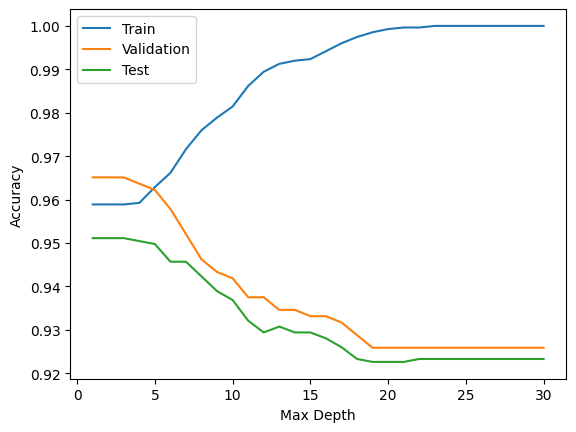

In [ ]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

print(X)
X_np = X.to_numpy()  # Convert DataFrame to NumPy array
print(X)
X_train, X_test, y_train, y_test = train_test_split(X_np, y, test_size=0.3, random_state=42)


print(X_train.shape, X_test.shape)  # Check dataset shape

# Train the decision tree
tree = DecisionTree(max_depth=5)
tree.train(X_train, y_train)

# Make predictions
y_pred = predict(tree, X_test)

# Evaluate accuracy
accuracy = np.mean(y_pred == y_test)
print(f"Test Accuracy: {accuracy:.2f}")


# Splitting into training and validation sets
X1_train,X_val,y1_train,y_val = train_test_split(X_train,y_train,test_size=0.2,random_state=42)


# Finding accuracy
y_train_pred = predict(tree, X1_train)
training_accuracy = np.mean(y_train_pred == y1_train)
print(f"Train Accuracy: {training_accuracy:.2f}")



y_val_pred = predict(tree, X_val)
validation_accuracy = np.mean(y_val_pred == y_val)
print(f"Validation Accuracy: {validation_accuracy:.2f}")



# Plotting accuracies as max depth is changed from 1 to 30
train_accuracies = []# initiallizing lists
val_accuracies = []
test_accuracies = []
depth_range = range(1,31)
for depth in depth_range:# looping through max depths from 1 to 30
  tree = DecisionTree(max_depth=depth)
  tree.train(X1_train, y1_train)

  y_train_pred = predict(tree, X1_train)# making predictions
  y_val_pred = predict(tree, X_val)
  y_test_pred = predict(tree, X_test)

  train_accuracies.append(np.mean(y_train_pred == y1_train))# finding accuracies
  val_accuracies.append(np.mean(y_val_pred == y_val))
  test_accuracies.append(np.mean(y_test_pred == y_test))

plt.plot(depth_range, train_accuracies, label='Train')# plotting
plt.plot(depth_range, val_accuracies, label='Validation')
plt.plot(depth_range, test_accuracies, label='Test')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
